In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
merged_path = repository.download_dataset(
    name="kang_29K_ctrl-ifnb_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / "counts.zarr")
repack_store(
    f"{merged_path}/data.zarr",
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / "batch_analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
)
ds.pipeline.run(
    filtering=False,
    cell_cycle_scoring=False,
    highly_variable_features={
        "min_cells": 10,
        "top_n": 2000,
        "min_mean": -3,
        "max_mean": 2,
        "max_var": 6,
    },
    pca={"dims": 25},
    neighbors={"k": 21},
    umap={
        "n_epochs": 250,
        "spread": 5,
        "min_dist": 1,
        "parallel": True,
    },
    leiden={1.0: {"label": "integration_clusters"}},
    paris=False,
    doublet_scoring=False,
    markers=False,
)

baseline = ds.get_assay_state("RNA")
normalized = baseline.normalized
pca_full = baseline.reduction
uncorrected_neighbors = baseline.neighbors
uncorrected_graph = baseline.connectivity_map


def integration_scores(neighbors, graph):
    return {
        "iLISI": ds.metric_ilisi(
            batch_colname="sample_id",
            neighbors=neighbors,
            perplexity=7,
        ),
        "cLISI": ds.metric_clisi(
            label_colname="orig_cluster_labels",
            neighbors=neighbors,
            perplexity=7,
        ),
        "graph connectivity": ds.metric_graph_connectivity(
            label_colname="orig_cluster_labels",
            graph=graph,
        ),
    }


scores = {
    "Uncorrected": integration_scores(
        uncorrected_neighbors,
        uncorrected_graph,
    )
}

Downloading bucket files: 97971591 / 97971591 complete

Downloading bytes: 97971591 / 97971591 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

...

Loading kmeans coordinates: 1 / 1 complete

Training UMAP: 250 / 250 complete

Computing LISI: 2 / 2 complete

Computing LISI: 2 / 2 complete

Computing graph connectivity: 4 / 4 complete

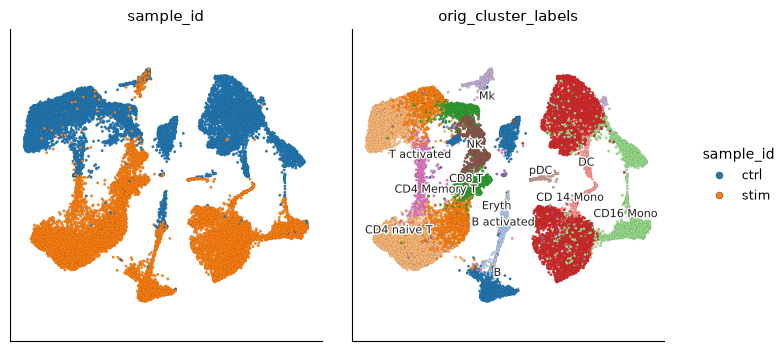

In [2]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=["sample_id", "orig_cluster_labels"],
    n_columns=2,
)

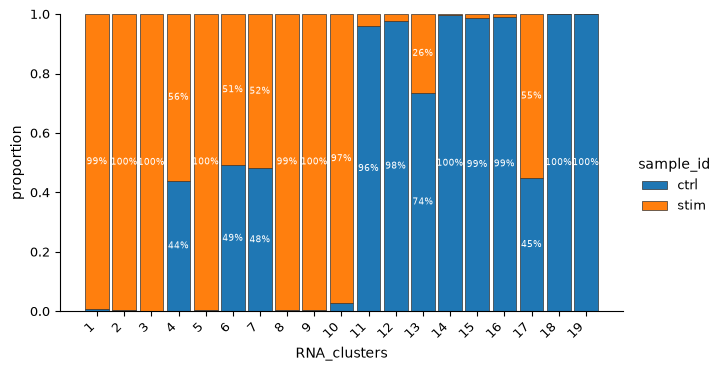

In [3]:
ds.plots.composition(
    category_by="sample_id",
    sample_by="RNA_clusters",
    kind="stacked",
    show_percent_labels=True,
)

In [4]:
pd.Series(scores["Uncorrected"]).round(3).rename("Uncorrected")

iLISI                 0.000
cLISI                 0.999
graph connectivity    0.949
Name: Uncorrected, dtype: float64

In [5]:
ds.cells.insert(
    column_name="is_ctrl",
    values=ds.cells.fetch_all("sample_id") == "ctrl",
    overwrite=True,
)
active = ds.cells.fetch_all("I").astype(bool)
is_ctrl = ds.cells.fetch_all("is_ctrl")
pd.Series(
    {
        "active cells": int(active.sum()),
        "reference (is_ctrl)": int(is_ctrl[active].sum()),
        "reference fraction": round(float(is_ctrl[active].mean()), 3),
    }
)

active cells           18597.000
reference (is_ctrl)     8486.000
reference fraction         0.456
dtype: float64

In [6]:
pca_partial = ds.run_pca(
    normalized,
    dims=25,
    pca_cell_key="is_ctrl",
)
ds.build_embedding_initialization(pca_partial)
partial_neighbors = ds.query_neighbors(
    ds.build_ann_index(pca_partial),
    k=21,
)
partial_graph = ds.build_connectivity_map(partial_neighbors)
ds.run_umap(
    graph=partial_graph,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label="partial_UMAP",
)
ds.run_leiden_clustering(
    graph=partial_graph,
    resolution=1.0,
    label="partial_clusters",
)
scores["Partial PCA"] = integration_scores(
    partial_neighbors,
    partial_graph,
)

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 2 / 2 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

Computing LISI: 2 / 2 complete

Computing LISI: 2 / 2 complete

Computing graph connectivity: 4 / 4 complete

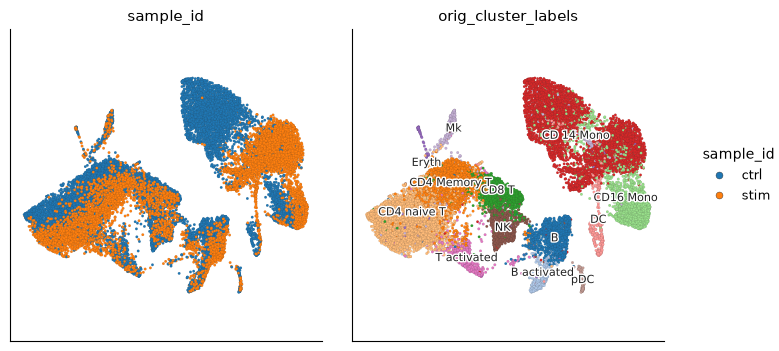

In [7]:
ds.plots.embedding(
    layout_key="RNA_partial_UMAP",
    color_by=["sample_id", "orig_cluster_labels"],
    n_columns=2,
)

In [8]:
corrected = ds.run_harmony(["sample_id"], pca_full)
ds.build_embedding_initialization(pca_full)
harmony_neighbors = ds.query_neighbors(
    ds.build_ann_index(corrected),
    k=21,
)
harmony_graph = ds.build_connectivity_map(harmony_neighbors)
ds.run_umap(
    graph=harmony_graph,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label="harmony_UMAP",
)
ds.run_leiden_clustering(
    graph=harmony_graph,
    resolution=1.0,
    label="harmony_clusters",
)
scores["Harmony"] = integration_scores(
    harmony_neighbors,
    harmony_graph,
)

Loading uncorrected latent dimensions: 1 / 1 complete

Harmonizing batches: 50 / 50 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

Computing LISI: 2 / 2 complete

Computing LISI: 2 / 2 complete

Computing graph connectivity: 4 / 4 complete

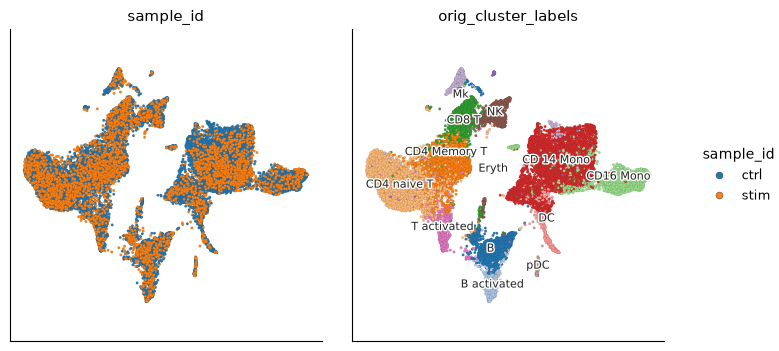

In [9]:
ds.plots.embedding(
    layout_key="RNA_harmony_UMAP",
    color_by=["sample_id", "orig_cluster_labels"],
    n_columns=2,
)

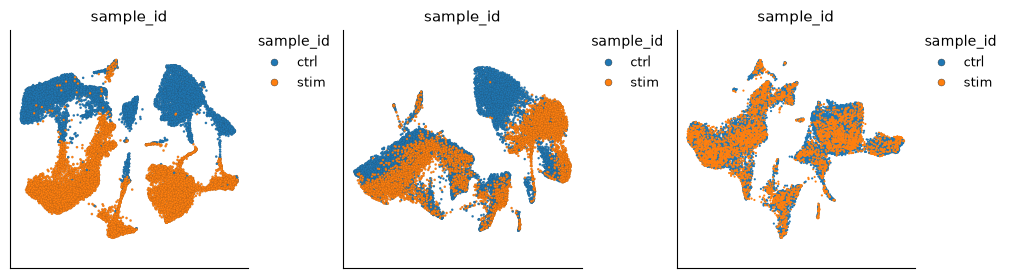

In [10]:
layouts = [
    "RNA_UMAP",
    "RNA_partial_UMAP",
    "RNA_harmony_UMAP",
]
ds.plots.embedding(
    layout_key=layouts,
    color_by="sample_id",
    n_columns=3,
    legend_loc="right",
)

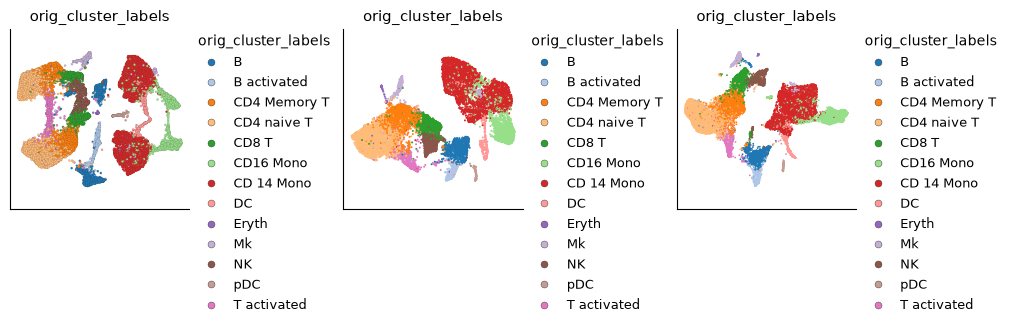

In [11]:
ds.plots.embedding(
    layout_key=layouts,
    color_by="orig_cluster_labels",
    n_columns=3,
    legend_loc="right",
)

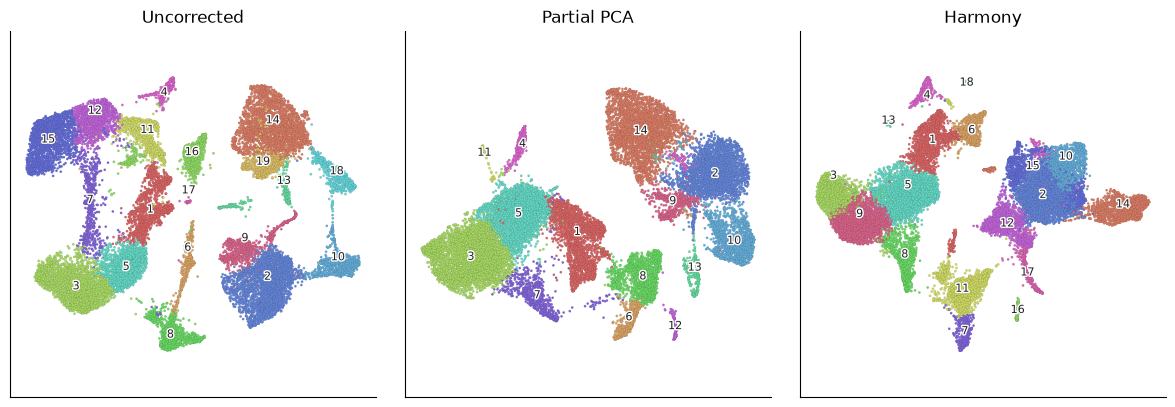

In [12]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
cluster_panels = (
    ("Uncorrected", "RNA_UMAP", "RNA_clusters"),
    ("Partial PCA", "RNA_partial_UMAP", "RNA_partial_clusters"),
    ("Harmony", "RNA_harmony_UMAP", "RNA_harmony_clusters"),
)
for axis, (title, layout_key, color_by) in zip(
    axes, cluster_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure

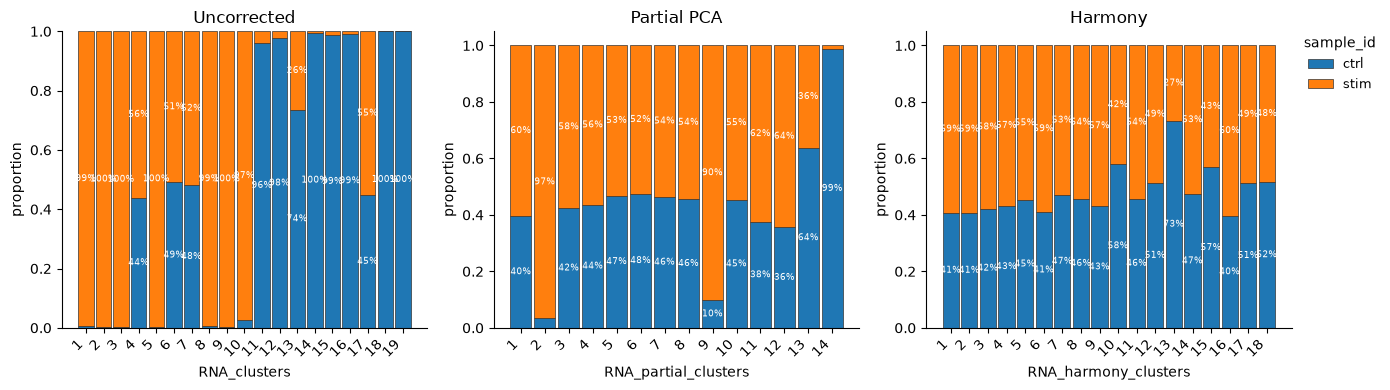

In [13]:
figure, axes = plt.subplots(1, 3, figsize=(14, 4))
composition_panels = (
    ("Uncorrected", "RNA_clusters"),
    ("Partial PCA", "RNA_partial_clusters"),
    ("Harmony", "RNA_harmony_clusters"),
)
for index, (axis, (title, sample_by)) in enumerate(
    zip(axes, composition_panels, strict=True)
):
    ds.plots.composition(
        category_by="sample_id",
        sample_by=sample_by,
        kind="stacked",
        show_percent_labels=True,
        show_legend=index == 2,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure

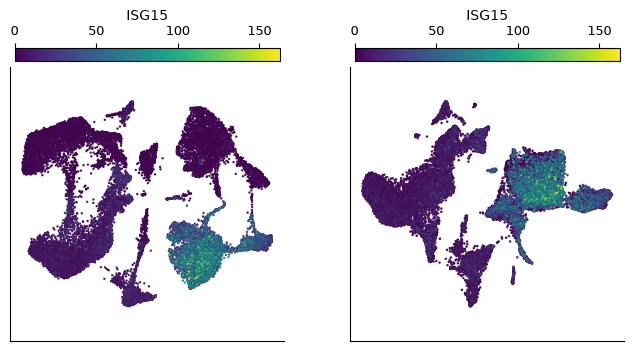

In [14]:
ds.plots.embedding(
    layout_key=["RNA_UMAP", "RNA_harmony_UMAP"],
    color_by="ISG15",
    n_columns=2,
    sort_values=True,
    legend_loc="right",
)

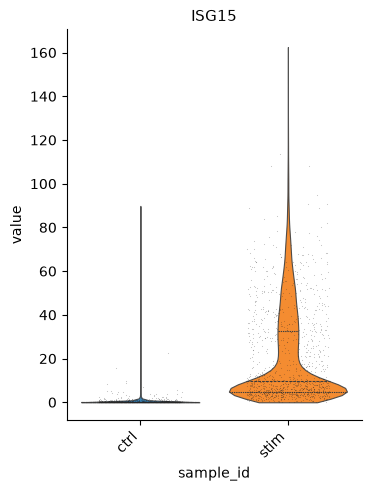

In [15]:
ds.plots.distribution(
    keys="ISG15",
    group_by="sample_id",
    kind="violin",
    max_points=2000,
    seed=0,
)

In [16]:
score_frame = pd.DataFrame.from_dict(scores, orient="index")
score_frame.round(3)

,iLISI,cLISI,graph connectivity
Uncorrected,0.000,0.999,0.949
Partial PCA,0.013,0.998,0.947
Harmony,0.493,0.999,0.947
